In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


In [2]:
data = pd.read_csv('PlayTennis.csv')
data.head(3)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes


In [3]:
from sklearn.preprocessing import OrdinalEncoder

In [4]:
Outlook_encoder = OrdinalEncoder()
data['Outlook'] = Outlook_encoder.fit_transform(data[['Outlook']])
data.head(3)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,Hot,High,Weak,No
1,2.0,Hot,High,Strong,No
2,0.0,Hot,High,Weak,Yes


In [5]:
Temp_encoder = OrdinalEncoder()
data['Temperature'] = Temp_encoder.fit_transform(data[['Temperature']])

Humidity_encoder = OrdinalEncoder()
data['Humidity'] = Humidity_encoder.fit_transform(data[['Humidity']])

Wind_encoder = OrdinalEncoder()
data['Wind'] = Wind_encoder.fit_transform(data[['Wind']])

Play_encoder = OrdinalEncoder()
data['Play Tennis'] = Play_encoder.fit_transform(data[['Play Tennis']])

data.head(3)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0


In [6]:
x = data.drop(["Play Tennis"] , axis=1)
y = data["Play Tennis"]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )


In [9]:
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

In [11]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(x_train, y_train)

y_pred_entropy = clf_entropy.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy with Gini: ", accuracy_score(y_test, y_pred))
print("Classification report:\n ", classification_report(y_test, y_pred))
print("Confusion_matrix with Gini:\n ", confusion_matrix(y_test, y_pred))

Accuracy with Gini:  1.0
Classification report:
                precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion_matrix with Gini:
  [[1 0]
 [0 2]]


Overfit in above results

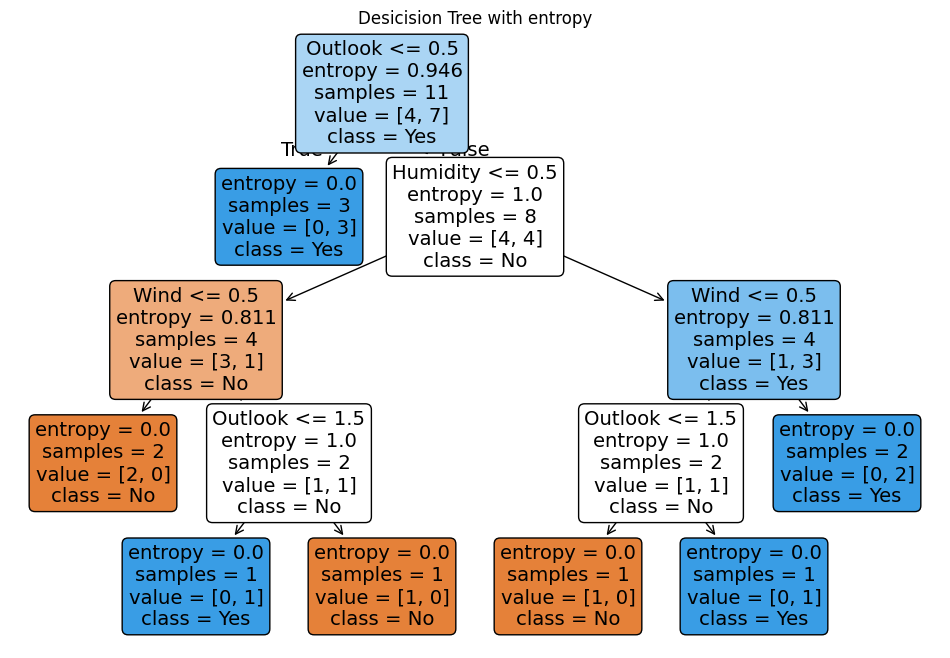

In [17]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_entropy, filled=True, 
                            feature_names=x.columns, 
                            class_names=Play_encoder.categories_[0],
                            rounded=True)

plt.title("Desicision Tree with entropy")
plt.show()